# GIẢI THUẬT 2: SUPPORT VECTOR MACHINE (SVM)

## 1. Ôn tập lý thuyết

**1) Giải thuật Support Vector Machine hoạt động như thế nào? Hãy giải thích khái niệm về ranh giới phân tách (hyperplane) và lề (margin)**
- **Siêu phẳng (hyperplane)** phân tách hai lớp trong không gian đặc trưng được mô tả bởi phương trình:
$$
\mathbf{w}^\top \mathbf{x} + b = 0
$$

- **Lề (margin)** là khoảng cách từ các điểm gần nhất của mỗi lớp đến siêu phẳng. SVM tìm nghiệm sao cho **lề lớn nhất**. Bài toán chuẩn tắc (tuyến tính, tách được) là:
$$
\min_{\mathbf{w}, b} \; \frac{1}{2}\lVert \mathbf{w} \rVert^2 \quad \text{s.t. } y_i(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1 \;\; \forall i
$$

> Trực giác: trong vô hạn siêu phẳng có thể phân tách, SVM chọn siêu phẳng **an toàn nhất** (lề lớn).


**2) Các vector hỗ trợ (support vectors) có vai trò gì trong SVM? Tại sao chúng quan trọng?**
- **Support vectors** là các điểm **nằm sát lề** (các ràng buộc hoạt tính).  
- Chúng **quyết định trực tiếp** vị trí của siêu phẳng tối ưu; các điểm ở xa hơn **không ảnh hưởng** đến nghiệm.  
- Nhờ đó mô hình **gọn** và **ổn định** hơn (dựa vào một tập con dữ liệu quan trọng).

**3) Sự khác biệt giữa SVM với lề cứng (hard margin) và lề mềm (soft margin) là gì? Khi nào nên sử dụng lề mềm?**
- **Hard margin:** yêu cầu phân tách **hoàn hảo** (không lỗi). Phù hợp khi dữ liệu thật sự **tách tuyến tính** và **ít nhiễu**.  
- **Soft margin:** cho phép một số **vi phạm lề**; tối ưu hóa cân bằng giữa **lề rộng** và **ít lỗi** nhờ tham số phạt $C$:
$$
\min_{\mathbf{w}, b, \boldsymbol{\xi}} \; \frac{1}{2}\lVert \mathbf{w} \rVert^2 + C \sum_i \xi_i \quad
\text{s.t. } y_i(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1 - \xi_i, \;\; \xi_i \ge 0
$$

>  Hầu hết bài toán thực tế (dữ liệu nhiễu/không tách tuyến tính).

**4) Hàm nhân (kernel) trong SVM là gì? Hãy giải thích các loại kernel phổ biến (linear, polynomial, RBF) và khi nào nên sử dụng chúng**

**Kernel trick:** thay vì biến đổi phi tuyến tường minh, ta dùng **hàm nhân (kernel)** để tính tích vô hướng trong không gian đặc trưng ẩn.

- **Linear**: $K(\mathbf{x},\mathbf{z})=\mathbf{x}^\top\mathbf{z}$  
  - Dùng khi dữ liệu **gần tuyến tính**, đặc trưng **cao và thưa** (VD: bag-of-words).
- **Polynomial**: $K(\mathbf{x},\mathbf{z})=(\gamma\,\mathbf{x}^\top\mathbf{z}+r)^{d}$  
  - Mô hình hóa **tương tác đa thức**; cẩn trọng với **bậc cao** vì dễ quá khớp.
- **RBF (Gaussian)**: $K(\mathbf{x},\mathbf{z})=\exp(-\gamma\lVert \mathbf{x}-\mathbf{z}\rVert^2)$  
  - Linh hoạt, thường là **mặc định mạnh** khi **không biết** dạng phi tuyến. Cần tune đồng thời **$C$** và **$\gamma$**.

**5) Tham số C trong SVM có ý nghĩa gì? Nó ảnh hưởng như thế nào đến hiệu suất của mô hình?**
- **$C$ lớn** → phạt nặng lỗi → cố gắng **ít lỗi huấn luyện**, **lề hẹp**, nguy cơ **overfit** cao hơn.  
- **$C$ nhỏ** → cho phép nhiều vi phạm hơn → **lề rộng**, có thể **tổng quát hóa** tốt hơn (tăng bias, giảm variance).

- Với RBF, còn có **$\gamma$**:  
  - $\gamma$ lớn → ranh giới **gồ ghề** (variance cao).  
  - $\gamma$ nhỏ → ranh giới **mượt** (bias cao).


**6) Viết đoạn code mẫu bằng Python (sử dụng Scikit-learn) để xây dựng một mô hình SVM cho bài toán phân loại không? Hãy mô tả các bước thực hiện**
Quy trình: tách X/y → chia train/test (stratify) → **scaling** → chọn kernel/siêu tham số → fit & đánh giá.



In [ ]:

# Demo SVM với dữ liệu toy
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# 1) Tạo dữ liệu mẫu
X, y = make_classification(
    n_samples=1200, n_features=10, n_informative=5, n_redundant=2,
    class_sep=1.5, random_state=42
)
df = pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])
df["target"] = y

# 2) Tách dữ liệu
X = df.drop(columns=["target"])
y = df["target"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3) Pipeline: scale -> SVC(RBF)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf"))
])

# 4) Tuning cơ bản
param_grid = {
    "clf__C": [0.1, 1, 10],
    "clf__gamma": ["scale", 0.1, 0.01]
}
grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1, scoring="f1_macro")
grid.fit(Xtr, ytr)

print("Best params:", grid.best_params_)
yp = grid.predict(Xte)
print("== Classification Report ==")
print(classification_report(yte, yp))
print("Confusion matrix:\n", confusion_matrix(yte, yp))


**Nhận xét:**


**7) Hàm nào trong Scikit-learn để chuẩn hóa dữ liệu (scaling) trước khi áp dụng SVM? Tại sao bước này quan trọng?**
- Dùng **`StandardScaler`** (module `sklearn.preprocessing`) để đưa mỗi đặc trưng về **trung bình 0, độ lệch chuẩn 1**.  
- Với SVM (đặc biệt **RBF/Polynomial**), khoảng cách giữa các điểm bị ảnh hưởng mạnh bởi **thang đo**; không scale có thể làm một số đặc trưng **lấn át** phần còn lại và khiến tối ưu hóa **kém ổn định**.

Ví dụ tích hợp trong `Pipeline` (đã dùng ở phần 6):

In [ ]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf"))
])
pipe


**Nhận xét:**

## 2. Bài làm mẫu

### 2.1 Bài toán 1: Thực hiện các nhiệm vụ trong bài toán 1 để xây dựng mô hình với giải thuật SVM cho dữ liệu Iris-data

#### 2.1.1 Nhiệm vụ 1: Xây dựng mô hình SVM để phân loại các loài hoa cẩm chướng

##### 1.Import thư viện và load dữ liệu

In [1]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
# Download&Load dữ liệu iris từ datasets của scikit-learn
iris = datasets.load_iris()
# Hiển thị mô ta dữ liệu, chỉ có trong các bộ dữ liệu chuẩn và mở để học tập và nghiên cứu
print(iris.DESCR)
# Từ tập dữ liệu ban đầu, tách lấy ma trận biểu diễn các đặc trưng và nhãn.
data = iris.data
target = iris.target
# TODO: Chia dữ liệu và nhãn thành 2 tập dữ liệu huấn luyện và dữ liệu kiểm tra theo tỉ lệ 80:20
X_train, X_test, y_train, y_test = train_test_split(data, target,
test_size
= 0.2, random_state=101)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

**Nhận xét:**

##### 2. Tạo mô hình SVM với dữ liệu đã chuẩn bị

In [2]:
from sklearn import svm
# khởi tạo mô hình phân lớp
clf = svm.SVC()
# Sử dụng phương thức 'fit' để huấn luyện mô hình với dữ liệu huấn luyện và nhãn huấn luyện
# fit (X,Y) với X là tập các đối tượng, Y là tập nhãn tương ứng của đối tượng.
clf.fit(X_train, y_train)

SVC()

**Nhận xét:**

##### 3. Đánh giá độ chính xác của mô hình

In [3]:
# Tính độ chính xác trên tập huấn luyện và tập kiểm tra
train_acc = clf.score(X_train,y_train)
val_acc = clf.score(X_test,y_test)
print('Training accuracy: {}'.format(train_acc))
print('Validation accuracy: {}'.format(val_acc))

Training accuracy: 0.95
Validation accuracy: 0.9666666666666667


**Nhận xét:**

##### 4. Tìm tham số kernel tối ưu cho mô hình SVM

In [5]:
# best_svm, best_val_acc và best_kernel lần lượt là các biến lưu mô hình tốt nhất,
# độ chính xác cao nhất trên tập kiểm tra và kernel tốt nhất
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_svm = None
best_val_acc = -1
best_kernel = None
# Huấn luyện các mô hình dựa trên dữ liệu huấn luyện và tham số kernel
# Tính toán độ chính xác trên tập huấn luyện và tập kiểm tra để tìm được mô hình tốt nhất
for i in range(4):
    clf = svm.SVC(kernel=kernels[i], probability=True)
    clf.fit(X_train, y_train)
    tmp_val_acc = clf.score(X_test, y_test)
    if (tmp_val_acc > best_val_acc):
        best_val_acc = tmp_val_acc
        best_svm = clf
        best_kernel = kernels[i]
# Hiển thị mô hình tốt nhất cùng với độ chính xác
print("Best validation accuracy : {} with kernel: {}".format(best_val_acc,
best_kernel))
# Mô hình tốt nhất của bạn nên có độ chính xác xấp xỉ 86,67%

Best validation accuracy : 1.0 with kernel: linear


**Nhận xét:**

Ghi chú: Sinh viên có thể sử dụng GridSearchCV để tìm tham số tối ưu cho mô hình SVM trên.

### 2.2 Bài toán 2: Xây dựng mô hình dựa vào giải thuật SVM trên dữ liệu hình ảnh Handwritten-Digit-MNIST-SVM.

#### 2.2.1 Nhiệm vụ 1: Tìm hiểu về cách biểu diễn và hiển thị các ảnh từ tập dữ liệu là hình ảnh

##### 1. Import thư viện và tải dữ liệu là tập các hình ảnh viết tay từ số 0 đến số 9

In [6]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
digits = load_digits(n_class=10)

##### 2. Khảo sát thông tin có trong digits

In [7]:
#thông tin toàn bộ dữ liệu đã tải về 
digits
#xem thông tin của một hình dưới dạng ma trận 8 x 8
digits['data'][0].reshape(8,8)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

**Nhận xét:**

In [8]:
#xem thông tin của một hình dưới dạng mảng
digits['data'][0]
#xem thông tin 9 nhãn đầu tiên
digits['target'][0:9]

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

**Nhận xét:**

##### 3. Vẽ ra hình dựa vào dữ liệu dạng ma trận 8 x 8

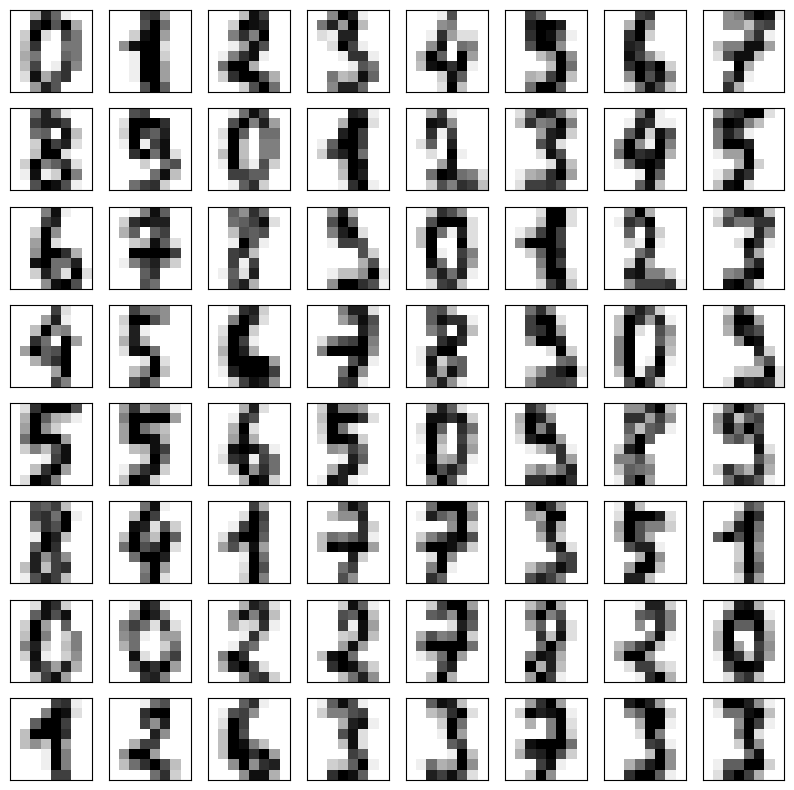

In [13]:
# Each Digit is represented in digits.images as a matrix of 8x8 = 64 pixels. Each of the 64 values represent
# a greyscale. The Greyscale are then plotted in the right scale by the imshow method.
fig, ax = plt.subplots(8,8, figsize=(10,10))
for i, axi in enumerate(ax.flat):
    axi.imshow(digits.images[i], cmap='binary')
    axi.set(xticks=[], yticks=[])

**Nhận xét:**

##### 4. Vẽ một ảnh từ ma trận 8 x 8

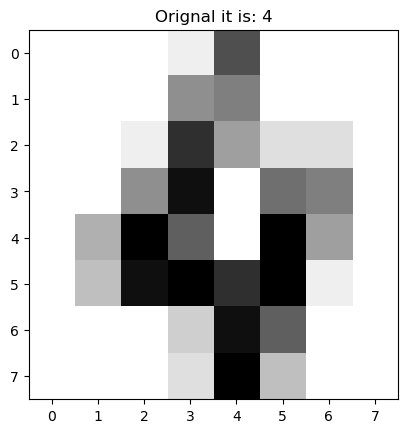

In [14]:
# Hàm vẽ 1 ảnh có kích thước 8 x 8 (ảnh lấy từ ma images)
def view_digit(index):
    plt.imshow(digits.images[index] , cmap = plt.cm.gray_r)
    plt.title('Orignal it is: '+ str(digits.target[index]))
    plt.show()
    # vẽ ảnh ở vị trí thứ 4
view_digit(4)

**Nhận xét:**

#### 2.2.2 Nhiệm vụ 2: Xây dựng mô hình SVM để nhận diện chữ viết tay từ 0 – 9

##### 1. Chuẩn bị dữ liệu và xây dựng mô hình SVM

In [16]:
# Thực hiện import các thư viện cần thiết để xây dựng mô hình SVM
# Thực hiện bước 1 của nhiệm vụ 1
from sklearn import svm
main_data = digits['data']
targets = digits['target']
svc = svm.SVC(gamma=0.001 , C = 100)
# GAMMA is a parameter for non linear hyperplanes.
# The higher the gamma value it tries to exactly fit the training data set
# C is the penalty parameter of the error term.
# It controls the trade off between smooth decision boundary and classifying the training points correctly.
svc.fit(main_data[:1500] , targets[:1500])
predictions = svc.predict(main_data[1501:])
# list(zip(predictions , targets[1501:]))

**Nhận xét:**

##### 2. Đánh giá hiệu quả của mô hình với Confusion Matrix

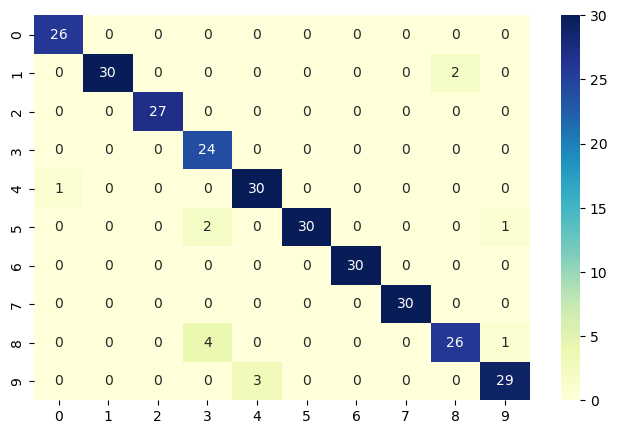

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(predictions, targets[1501:])
conf_matrix = pd.DataFrame(data = cm)
plt.figure(figsize = (8,5))
sns.heatmap(conf_matrix, annot=True,fmt='d',cmap="YlGnBu");

**Nhận xét:**

##### 3. In kết quả dạng văn bản

In [18]:
from sklearn.metrics import classification_report
print(classification_report(predictions, targets[1501:]))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.94      0.97        32
           2       1.00      1.00      1.00        27
           3       0.80      1.00      0.89        24
           4       0.91      0.97      0.94        31
           5       1.00      0.91      0.95        33
           6       1.00      1.00      1.00        30
           7       1.00      1.00      1.00        30
           8       0.93      0.84      0.88        31
           9       0.94      0.91      0.92        32

    accuracy                           0.95       296
   macro avg       0.95      0.96      0.95       296
weighted avg       0.96      0.95      0.95       296



**Nhận xét:**

### 2.3 Bài tập thực hành 1: Xây dựng mô hình từ giải thuật SVM trên dữ liệu bệnh tiểu đường.

### 2.4 Bài tập thực hành 2: Xây dựng mô hình từ giải thuật SVM trên dữ liệu các con thú trong rừng. 